In [211]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
# from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator, StatevectorSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes,RZGate, PauliEvolutionGate, HamiltonianGate, SwapGate, CXGate
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.ticker as ticker
#from qiskit.circuit.library.generalized_gates import RXXGate, RYYGate, RZZGate
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import RGate, ZGate, MCXGate, CXGate, ECRGate, CU3Gate
from qiskit.circuit import Gate
from scipy.linalg import expm
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit_ibm_runtime import SamplerV2 as Sampler
#from tqdm import tqdm
import time
from qiskit.quantum_info import Operator
from qiskit.providers import JobStatus
from qiskit_aer import Aer
import qiskit as qk

In [212]:
from qiskit.quantum_info import Operator, Pauli
from qiskit.quantum_info.operators import SparsePauliOp
from scipy.linalg import expm
from scipy.linalg import svd
from scipy.constants import physical_constants
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
from qiskit.synthesis import TwoQubitBasisDecomposer
from tqdm import tqdm

In [213]:
# # noiseless implementation
# #sampler = StatevectorSampler()
# # simulator=AerSimulator(method="statevector")
# #simulator = Aer.get_backend("qasm_simulator")

# service = QiskitRuntimeService()
# backend = service.backend('ibm_sherbrooke')
# # backend = AerSimulator(method='statevector')
# # backend = AerSimulator.from_backend(backend)
# sampler = Sampler(backend)

simulator_flag = True
noiseless_flag = True
linear_noiseless_flag = False # use linear connectivity from IBM Sherbrooke, but noiseless

config = None

if simulator_flag:
    if linear_noiseless_flag:
        config = FakeSherbrooke().configuration()
        coupling_map = config.coupling_map
        simulator = AerSimulator(method='statevector', coupling_map=coupling_map, noise_model=None)
    else:
        if not noiseless_flag:
            # noise model from sherbrooke
            service = QiskitRuntimeService()
            simulator = AerSimulator(method='statevector').from_backend(service.backend('ibm_sherbrooke'))
            config = FakeSherbrooke().configuration()
        else:
            # noiseless
            simulator = AerSimulator(method="statevector")
else:
    service = QiskitRuntimeService()
    backend = service.backend('ibm_sherbrooke')
    sampler = Sampler(backend)
    config = backend.configuration()

explicit_swap_flag = True

PMNS_TYPE = 1

In [214]:
# temp_backend = FakeSherbrooke()
# config = temp_backend.configuration()
# print(f"Backend: {config.backend_name}")
# print(f"    Processor type: {config.processor_type}")
# print(f"    Supported instructions:")
# for instruction in config.supported_instructions:
#     print(f"        {instruction}")
# print()

In [215]:
# print(backend)

In [216]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####

def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP, cp_sign=1):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)

    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U
    return U_4x4


theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0
N = 8

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
print(mu)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
print (omega, Omega)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

def theta_ij(i, j):
    return np.arccos(0.9) * np.abs(i-j) / (N-1)

def J_ij(i, j, E):
    return  mu/(N) * (1 - np.cos(theta_ij(i, j))) * 1
print(theta_ij(0,1))
print (J_ij(0,1,E))

0.01002
3.705e-05 0.0012525
0.06443240168518034
2.5989990703006474e-06


In [217]:
def anti_CU3(qc, i, j, theta, phi, delta):
    """
    Apply the anti-CU3 gate to qubits i and j.
    """
    qc.x(i)
    qc.append(CU3Gate(theta, phi, delta), [i, j])
    qc.x(i)

def anti_CNOT(qc, i, j):
    """
    Apply the anti-CNOT gate to qubits i and j.
    """
    qc.x(i)
    qc.append(CXGate(), [i, j])
    qc.x(i)

def PMNS_4x4_decomp(theta_12, theta_13, theta_23, delta_CP):
    """
    Decompose PMNS into 3 rotations according to arXiv:2111.05401
    assume operating on qubit i and i+1
    """
    qc = QuantumCircuit(2)

    anti_CU3(qc, 0, 1, theta_12, 0, 0)
    anti_CU3(qc, 1, 0, -2*theta_13, delta_CP, -delta_CP)
    anti_CNOT(qc, 1, 0)
    anti_CU3(qc, 0, 1, 2*theta_23, 0, 0)
    anti_CNOT(qc, 1, 0)

    return qc.to_gate(label='PMNS_4x4')

def PMNS_dagger_4x4_decomp(theta_12, theta_13, theta_23, delta_CP):
    """
    Decompose PMNS into 3 rotations according to arXiv:2111.05401
    assume operating on qubit i and i+1
    """
    pmns = PMNS_4x4_decomp(theta_12, theta_13, theta_23, delta_CP)
    qc = pmns.inverse()

    return qc


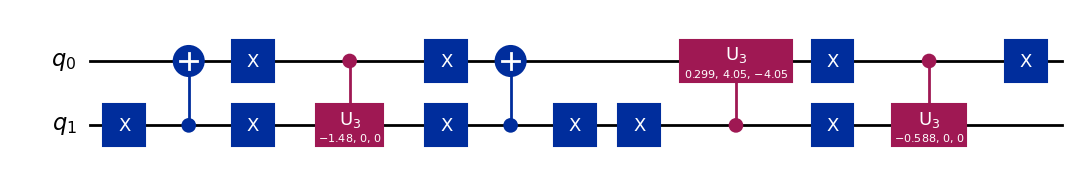

In [218]:
qc=QuantumCircuit(2)
qc.append(PMNS_dagger_4x4_decomp(theta_12, theta_13, theta_23, delta_CP), [0, 1])
qc.decompose().draw('mpl')

In [219]:
def U1_omega_Omega(t):
    A = -1 * omega * t
    B_val = -1 * Omega * t
    gate = QuantumCircuit(2)
    gate.rz(A, 0)
    gate.rz(B_val, 1)
    return gate.to_gate(label='U1_omega_Omega')


In [220]:
def nunu_interaction(qc, q, alpha):
    a, b, c, d = q
    qc.cx(a, c)
    qc.cx(b, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(c, a)
    qc.cx(d, b)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.rz(-alpha, c)
    qc.rz(-alpha, d)
    qc.cx(a, c)
    qc.cx(b, d)
    qc.cx(a, b)
    qc.rz(-2 * alpha, b)
    qc.rz(alpha, c)
    qc.rz(alpha, d)
    qc.cx(a, b)
    qc.cx(b, c)
    qc.rz(alpha, c)
    qc.cx(a, c)
    qc.rz(-alpha, c)
    qc.cx(a, d)
    qc.cx(b, c)
    qc.rz(alpha, d)
    qc.cx(b, d)
    qc.rz(-alpha, d)
    qc.cx(a, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(d, b)
    qc.cx(c, a)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.cx(b, d)
    qc.cx(a, c)

def phase_gate(qc, q, p):
    phase = np.exp(1j * p) * np.eye(2)
    qc.unitary(phase, q, label='phase')

def nunu_interaction_p(qc, q, alpha, p=[np.pi/2, -np.pi/2, np.pi/4]):
    a, b, c, d = q
    qc.cx(a, c)
    qc.cx(b, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(c, a)
    qc.cx(d, b)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.rz(-alpha, c)
    qc.rz(-alpha + p[0], d)
    qc.cx(a, c)
    qc.cx(b, d)
    qc.cx(a, b)
    qc.rz(-2 * alpha + p[0], b)
    qc.rz(alpha, c)
    qc.rz(alpha + p[1], d)
    qc.cx(a, b)
    qc.cx(b, c)
    qc.rz(alpha + p[1], c)
    qc.cx(a, c)
    qc.rz(-alpha + p[0], c)
    qc.cx(a, d)
    qc.cx(b, c)
    qc.rz(alpha, d)
    qc.cx(b, d)
    qc.rz(-alpha, d)
    qc.cx(a, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(d, b)
    qc.cx(c, a)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.cx(b, d)
    qc.cx(a, c)

def two_qubit_swap(qc, q1, q2):
    # begin 0.0 0.1 1.0 1.1
    qc.swap(q1[1], q2[0]) # 0.0 1.0 0.1 1.1
    qc.swap(q2[0], q2[1]) # 0.0 1.0 1.1 0.1
    qc.swap(q1[0], q1[1]) # 1.0 0.0 1.1 0.1
    qc.swap(q1[1], q2[0]) # 1.0 1.1 0.0 0.1

    # qc.swap(q1[0], q2[0])
    # qc.swap(q1[1], q2[1]) 

In [221]:
# def apply_nunu_interaction(qc, pair_indices, alpha_list):
#     for i, j, alpha_ij in alpha_list:
#         q = [2*i, 2*i+1, 2*j, 2*j+1]
#         nunu_interaction(qc, q, alpha_ij)

def apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt):
    for i, j in pair_indices:
        # print(order)
        # print(base_pattern)
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        alpha_ij = J_ij(order[i], order[j], E) * dt
        # print("Interacting pairs: ", i, j)
        # print("Interacting qubits: ", q)
        # print("Interacting order: ", order)
        # print("Interacting base pattern: ", base_pattern)
        if explicit_swap_flag:
            nunu_interaction(qc, q, alpha_ij)
            two_qubit_swap(qc, [2*i, 2*i+1], [2*j, 2*j+1])
        else:
            nunu_interaction_p(qc, q, alpha_ij)
        order = swap_order_i_j(order, i, j)
        base_pattern = swap_base_pattern_i_j(base_pattern, i, j)
        # print("New order: ", order)
        # print("New base pattern: ", base_pattern)
    return order, base_pattern

def swap_order_i_j(order, i, j):
    order[i], order[j] = order[j], order[i]
    return order

def swap_base_pattern_i_j(base_pattern, i, j):
    base_pattern[i], base_pattern[j] = base_pattern[j], base_pattern[i]
    return base_pattern


In [222]:
def init_ordering():
    # pair_indices = [(i, j) for i in range(N) for j in range(i+1, N)]
    # every interaction we push the current first element to end of qubits
    # sort of like what happens in bubble sort
    pair_indices = []
    for j in range(N):
        nmj = N - j - 1
        for i in range(nmj):
            pair_indices.append((i, i+1))
    # print(pair_indices)
    # this should totally reverse the order of the qubits
    # i.e 1234 -> 4321
    order = [i for i in range(N)] # initial order (physical mapping to neutrinos)

    # Target initial state pattern: 00 01 00 10 00 01 00 10 ...
        # Target initial state pattern based on same logic as initial state
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('M')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('T')  # nu_tau
        else:
            base_pattern.append('E')  # nu_e
        # Reverse the *pairs*, not individual bits
    return pair_indices, order, base_pattern

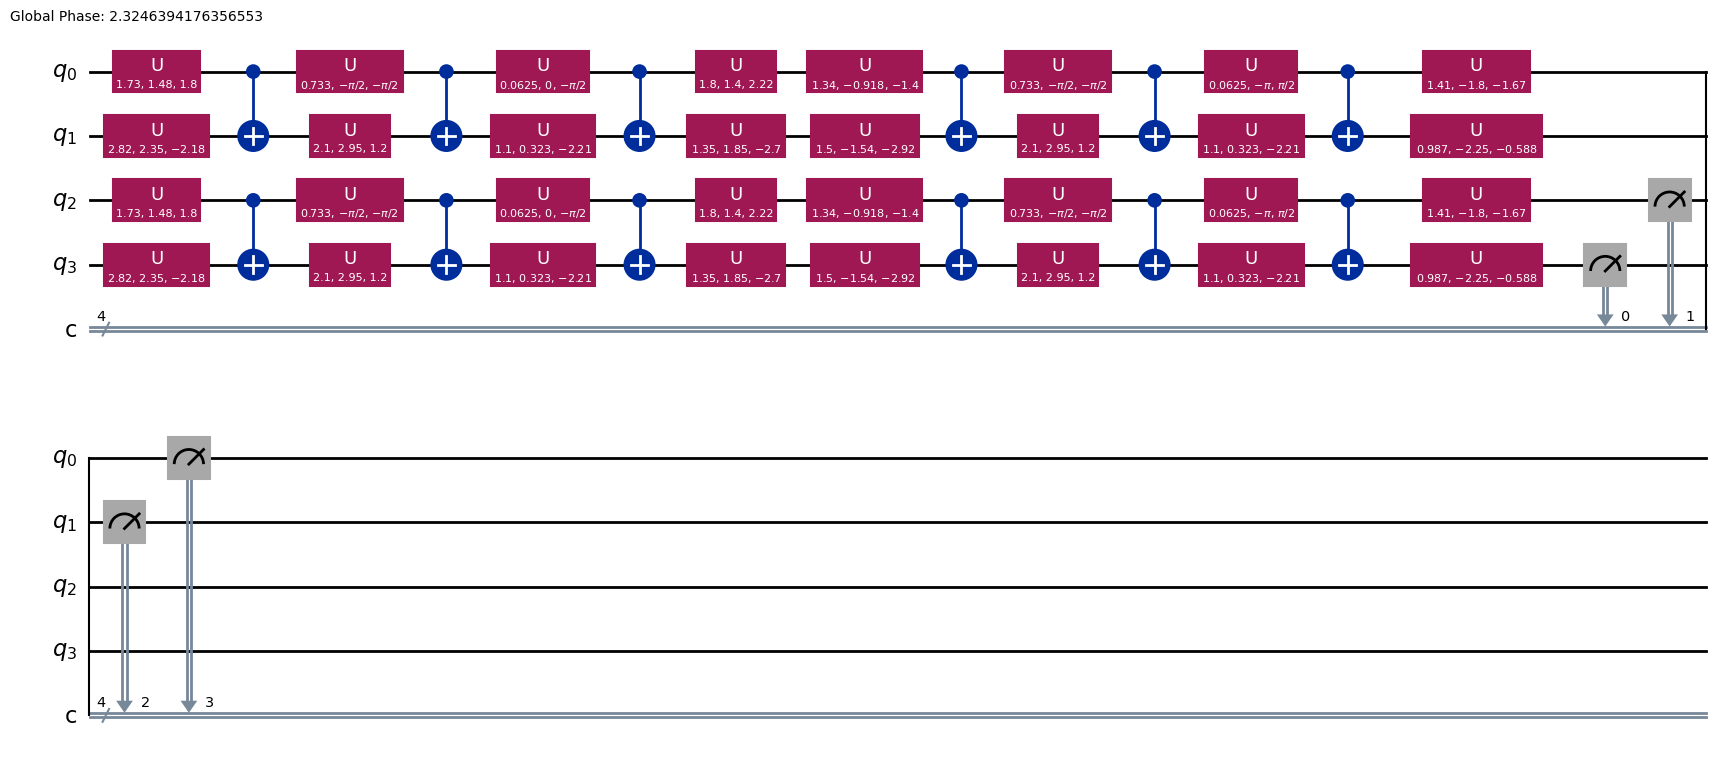

In [223]:
qc = QuantumCircuit(4, 4)

# Apply U†_PMNS
Udag = Operator(U_PMNS_4x4.conj().T)
qc.unitary(Udag, [0, 1], label="U†_PMNS")
qc.unitary(Udag, [2, 3], label="U†_PMNS")

# Apply U_PMNS
U = Operator(U_PMNS_4x4)
qc.unitary(U, [0, 1], label="U_PMNS")
qc.unitary(U, [2, 3], label="U_PMNS")

# Measurement
# if order[-1] > order[0]:
qc.measure(range(4), reversed(range(4)))
qc.decompose(reps=1).draw('mpl')

  0%|          | 0/5 [00:00<?, ?it/s]

Target state: 0001001000010010
Measurement counts: {'0001001000010010': 8192}


 40%|████      | 2/5 [00:05<00:08,  2.91s/it]

Target state: 1000010010000100
Measurement counts: {'1000010001010110': 1, '1010000010010100': 1, '1000000101000101': 1, '0000100010101000': 1, '0100000010000101': 2, '0000010010101010': 1, '0000010001001000': 1, '0000100010001010': 1, '0100010001000101': 1, '0010011010000110': 1, '1000000010000110': 1, '0000000001000110': 1, '1000010010001001': 3, '0100010010101000': 1, '0101010010001000': 2, '0000010001100100': 1, '1000000010010101': 1, '0000010000000100': 1, '0100010110000000': 1, '1000000001000101': 1, '1000100110000110': 1, '1000010000000110': 2, '1000000000000100': 2, '1000100010010000': 1, '1001010010010100': 2, '1000100001001000': 4, '1000010010010110': 1, '0001010010100100': 2, '0000010010010100': 1, '0101010010000000': 3, '1000100010101000': 1, '0100100010100100': 2, '1000101010000100': 1, '1000100001100100': 1, '0100100101000100': 1, '0100010010000000': 2, '1000010000100100': 3, '1010010100001000': 1, '1000100001000110': 1, '0110010010001000': 1, '1000010100000100': 3, '0000

 60%|██████    | 3/5 [00:06<00:03,  1.78s/it]

Target state: 0001001000010010
Measurement counts: {'0001011000101010': 1, '0001000001001001': 1, '0001001010000110': 1, '1010001010100000': 1, '0101001000000110': 1, '1010011000100000': 1, '0010000000010101': 1, '0001010110100010': 1, '0101011000001010': 1, '0010001001000110': 1, '0101100100010001': 1, '0001000110101001': 1, '0010101000010100': 1, '0000001001100100': 1, '0000000000010100': 1, '0110001001000010': 1, '0001100010010010': 1, '1001011000100000': 1, '1010011000100010': 1, '0001100001010001': 1, '0001101000101001': 1, '0101101001000010': 1, '0001000101100110': 1, '1000000000010010': 1, '0001010100100110': 1, '0001000000011000': 1, '0101001000010100': 1, '0101000000010000': 1, '1001000001010010': 2, '1010011000010010': 1, '0010001010001001': 1, '0001101000011000': 3, '0001101000011010': 1, '0000101000010100': 1, '0010101000011010': 1, '0000001010100110': 1, '0010000101100110': 1, '1001001010101010': 1, '0010011000000110': 1, '1001000100100101': 1, '0001101000101000': 1, '0000

 80%|████████  | 4/5 [00:06<00:01,  1.23s/it]

Target state: 1000010010000100
Measurement counts: {'1010001001000000': 1, '0100001001000000': 1, '1000000000100000': 1, '1001000001101000': 1, '0100100101010101': 1, '1001010000000001': 1, '0000010110001010': 1, '0000100000011001': 1, '1001000101000001': 1, '0000010000000001': 1, '0000010100000010': 1, '0001000101000100': 1, '0001100110100000': 1, '0101101010000000': 1, '0000010000101010': 1, '0010000010101010': 1, '1010010000010100': 1, '0101010010000101': 2, '1000100000101001': 1, '1001100110000001': 1, '1000000001010000': 1, '0001010101100110': 1, '1000000101011000': 1, '1001010010010100': 1, '1010100010001010': 1, '0000100000001000': 1, '1000000001100000': 1, '0100010001101001': 1, '1000000010010001': 1, '0101011000000000': 1, '1000010010010110': 1, '0001010010000101': 1, '0101100001100000': 1, '0000100000010101': 1, '0000000000000000': 1, '1001000001010000': 1, '1010100010010000': 1, '1000101010001001': 2, '0010010001000110': 1, '0110100000011000': 1, '0010010001011001': 1, '1010

100%|██████████| 5/5 [00:06<00:00,  1.35s/it]

Target state: 0001001000010010
Measurement counts: {'0110001000001001': 1, '1000010100010101': 1, '1010010110010000': 1, '0101100100010001': 1, '1001100110001001': 1, '0110000010010000': 1, '0010010101011010': 1, '0001010000011000': 1, '0110010110001000': 1, '0110100000001000': 1, '0000010000100110': 1, '0010010010000001': 1, '0101001000100101': 1, '0110010001100001': 1, '0110000010100101': 1, '1001100100010010': 1, '0010010100001000': 1, '0010010101000101': 1, '0110011000101000': 2, '1010100110101001': 1, '0001001010100110': 1, '0010001001100100': 1, '0010011001000110': 1, '1010011000000110': 1, '0001011000100110': 1, '1000100100001001': 1, '0010100110010101': 1, '1010010101000100': 1, '0010001010000100': 1, '1010001001010010': 1, '0001100110101001': 1, '1010100110010010': 1, '0010000001010010': 1, '0001000001100100': 1, '0101010100101001': 1, '1000010000000100': 1, '0001010000010001': 1, '0000001001100100': 1, '0110001001011001': 1, '1001000001100000': 1, '0100100001000000': 1, '0010

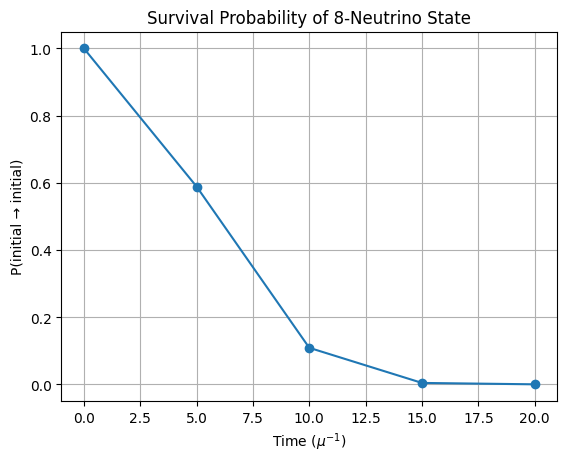

In [224]:
# Time loop setup for N neutrinos
dt = 5 / mu
T_max = 20 / mu
steps = int(T_max / dt) + 1
times = np.linspace(0, T_max, steps)

probabilities = [] # initial state survival probability
probabilities2 = [] # nu_0 survival probability
shots = 8192

for t in tqdm(times):
    qc = QuantumCircuit(2 * N, 2 * N)

    pair_indices, order, base_pattern = init_ordering()

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    if PMNS_TYPE == 0:
        Udag = Operator(U_PMNS_4x4.conj().T)
        for i in range(N):
            qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")
    elif PMNS_TYPE == 1:
        for i in range(N):
            qc.append(PMNS_dagger_4x4_decomp(theta_12, theta_13, theta_23, delta_CP), [2*i, 2*i+1])
    

    # Trotterization
    Trotter = int(t / dt)
    for _ in range(Trotter):
        # pair_alphas = [(i, j, J_ij(i, j, E) * dt) for i, j in pair_indices]
        for i in range(N):
            qc.append(U1_omega_Omega(dt), [2*i, 2*i+1])

        order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt)

    # Apply U_PMNS
    if PMNS_TYPE == 0:
        U = Operator(U_PMNS_4x4)
        for i in range(N):
            qc.unitary(U, [2*i, 2*i+1], label="U_PMNS")
    elif PMNS_TYPE == 1:
        for i in range(N):
            qc.append(PMNS_4x4_decomp(theta_12, theta_13, theta_23, delta_CP), [2*i, 2*i+1])
            
    # Measurement
    # if order[-1] > order[0]:
    qc.measure(range(2 * N), reversed((range(2 * N))))
    if t == times[1]:
        fig = qc.draw('mpl')
        fig.savefig("IBM_{0}_neutrinos_circuit.png".format(N))
    # else:
    #     qc.measure(reversed(range(2 * N)), reversed((range(2 * N))))
    pqc = None
    if simulator_flag:
        if config is not None:
            pqc = transpile(qc, simulator, optimization_level=3, basis_gates=config.supported_instructions)
        else:
            pqc = transpile(qc, simulator, optimization_level=3)
    else:
        # a long chain of qubits
        initial_layout = [i for i in range(13)]  + [17] + [i for i in reversed(range(18, 31))]
        initial_layout = initial_layout[:2*N]
        print("Running on chain of qubits")
        print(initial_layout)
        pqc = transpile(qc, backend, initial_layout = initial_layout, optimization_level=3, basis_gates=config.supported_instructions)
    #print(qc.count_ops())
    #for instr, qargs, cargs in qc.data:
        #if hasattr(instr, "params") and instr.params:
           # print(f"{instr.name}: {instr.params}")

    #pqc = transpile(qc, basis_gates=["u3", "cx"])
    counts = None
    job = None
    if simulator_flag:
        job = simulator.run([pqc], shots=shots)
    else:
        job = sampler.run([pqc], shots=shots)
    job_result = job.result()
    if simulator_flag:
        counts = job_result.get_counts()
    else:
        counts = job_result[0].data.c.get_counts()

    #print("Target state:", target_state)
    
    # we now form target state after the swapped order
    target_state = ''.join((base_pattern))
    # if order[-1] > order[0]:
        # we are in original order
    target_state = target_state.replace('M', '01')
    target_state = target_state.replace('T', '10')
    target_state = target_state.replace('E', '00')
    # else:
    #     # we are in swapped order
    #     print(target_state)
    #     target_state = target_state.replace('M', '10')
    #     target_state = target_state.replace('T', '01')
    #     target_state = target_state.replace('E', '00')
    
    print("Target state:", target_state)

    prob = counts.get(target_state, 0) / shots
    print("Measurement counts:", counts)
    probabilities.append(prob)

# Plot
plt.plot(times * mu, probabilities, marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel("P(initial → initial)")
plt.title("Survival Probability of {0}-Neutrino State".format(N))
plt.grid(True)
if not simulator_flag:
    plt.savefig("IBM_{0}_neutrinos.png".format(N))
    plt.savefig("IBM_{0}_neutrinos.pdf".format(N))

plt.savefig("PMNS_type_1.png")
plt.show()
